In [ ]:
#IMPLEMENTASI BAGGING DAN RANDOM FOREST
import numpy as np
import pandas as pd
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Single Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Bagging dengan Decision Tree
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Perbandingan
print("=" * 50)
print("Perbandingan Akurasi:")
print(f"Decision Tree: {accuracy_score(y_test, dt_pred):.4f}")
print(f"Bagging: {accuracy_score(y_test, bagging_pred):.4f}")
print(f"Random Forest: {accuracy_score(y_test, rf_pred):.4f}")

# Feature Importance dari Random Forest
importance = pd.DataFrame({
    "feature": data.feature_names,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 5 Feature Importance:")
print(importance.head())

Perbandingan Akurasi:
Decision Tree: 0.9415
Bagging: 0.9591
Random Forest: 0.9708

Top 5 Feature Importance:
                 feature  importance
7    mean concave points    0.141934
27  worst concave points    0.127136
23            worst area    0.118217
6         mean concavity    0.080557
20          worst radius    0.077975



Feature Importance:
              feature  importance
2  petal length (cm)    0.665677
3   petal width (cm)    0.318306
1   sepal width (cm)    0.014660
0  sepal length (cm)    0.001357
Perbandingan Boosting Methods:
AdaBoost: 0.9333
Gradient Boosting: 1.0000


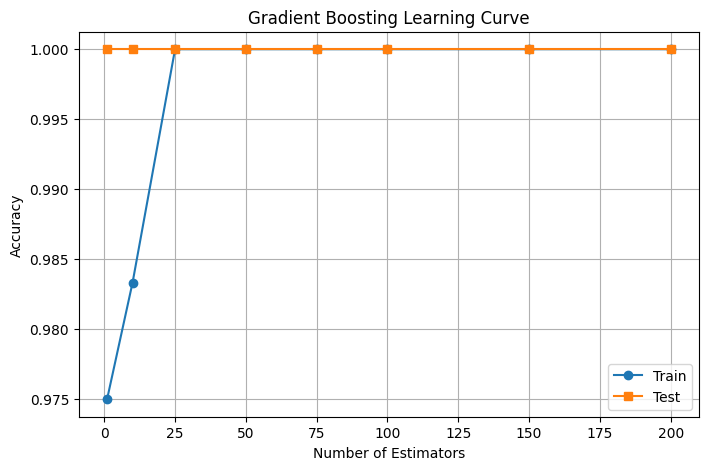

In [13]:
# =====================
# TAMBAHAN WAJIB (DATA + SPLIT)
# =====================
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================
# IMPORT
# =====================
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score

# =====================
# --- Bagian 1: AdaBoost ---
# =====================
try:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=50,
        learning_rate=1.0,
        random_state=42
    )
except TypeError:
    ada = AdaBoostClassifier(
        base_estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=50,
        learning_rate=1.0,
        random_state=42
    )

ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

# =====================
# --- Bagian 2: Gradient Boosting ---
# =====================
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42   # max_depth dihapus biar aman semua versi
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# =====================
# Feature Importance
# =====================
gb_importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:\n", gb_importance)

# =====================
# --- Bagian 3: Evaluasi ---
# =====================
print("=" * 50)
print("Perbandingan Boosting Methods:")
print(f"AdaBoost: {accuracy_score(y_test, ada_pred):.4f}")
print(f"Gradient Boosting: {accuracy_score(y_test, gb_pred):.4f}")

# =====================
# --- Bagian 4: Learning Curve ---
# =====================
train_scores = []
test_scores = []
estimators = [1, 10, 25, 50, 75, 100, 150, 200]

for n in estimators:
    gb_temp = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        random_state=42
    )
    gb_temp.fit(X_train, y_train)
    train_scores.append(gb_temp.score(X_train, y_train))
    test_scores.append(gb_temp.score(X_test, y_test))

# =====================
# --- Bagian 5: Plotting ---
# =====================
plt.figure(figsize=(8, 5))
plt.plot(estimators, train_scores, label='Train', marker='o')
plt.plot(estimators, test_scores, label='Test', marker='s')

plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting Learning Curve')
plt.legend()
plt.grid(True)
plt.show()


Feature Importance:
              feature  importance
2  petal length (cm)    0.665677
3   petal width (cm)    0.318306
1   sepal width (cm)    0.014660
0  sepal length (cm)    0.001357
PERBANDINGAN SEMUA METODE
Single Decision Tree : 1.0000
Bagging              : 1.0000
Random Forest        : 1.0000
AdaBoost             : 0.9333
Gradient Boosting    : 1.0000
Stacking             : 1.0000


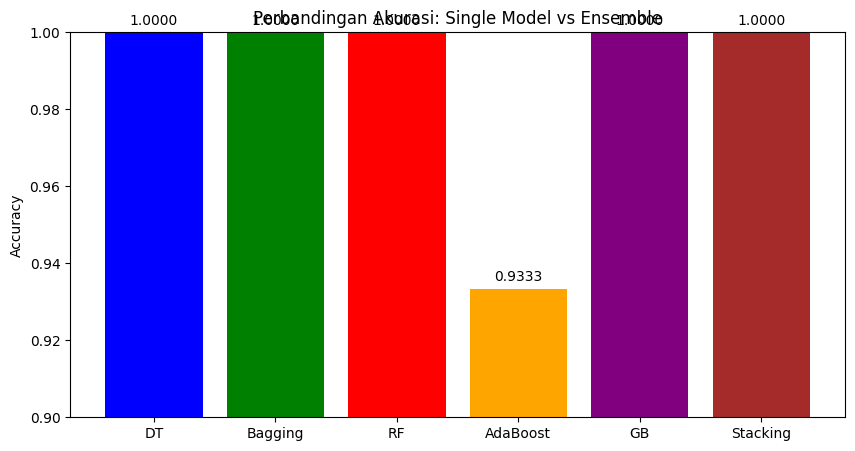

In [18]:
#IMPLEMENTASI STACKING
# =====================
# LOAD DATA + SPLIT
# =====================
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================
# IMPORT
# =====================
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# =====================
# DECISION TREE
# =====================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# =====================
# BAGGING
# =====================
try:
    bagging = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=50,
        random_state=42
    )
except TypeError:
    bagging = BaggingClassifier(
        base_estimator=DecisionTreeClassifier(),
        n_estimators=50,
        random_state=42
    )

bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)

# =====================
# RANDOM FOREST
# =====================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# =====================
# ADABOOST
# =====================
try:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=50,
        learning_rate=1.0,
        random_state=42
    )
except TypeError:
    ada = AdaBoostClassifier(
        base_estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=50,
        learning_rate=1.0,
        random_state=42
    )

ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

# =====================
# GRADIENT BOOSTING
# =====================
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# =====================
# FEATURE IMPORTANCE
# =====================
gb_importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:\n", gb_importance)

# =====================
# IMPLEMENTASI STACKING
# =====================
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

base_models = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

meta_learner = LogisticRegression(max_iter=1000)

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba'
)

stacking.fit(X_train, y_train)
stacking_pred = stacking.predict(X_test)

# =====================
# PERBANDINGAN
# =====================
print("=" * 50)
print("PERBANDINGAN SEMUA METODE")
print("=" * 50)

print(f"Single Decision Tree : {accuracy_score(y_test, dt_pred):.4f}")
print(f"Bagging              : {accuracy_score(y_test, bagging_pred):.4f}")
print(f"Random Forest        : {accuracy_score(y_test, rf_pred):.4f}")
print(f"AdaBoost             : {accuracy_score(y_test, ada_pred):.4f}")
print(f"Gradient Boosting    : {accuracy_score(y_test, gb_pred):.4f}")
print(f"Stacking             : {accuracy_score(y_test, stacking_pred):.4f}")

# =====================
# VISUALISASI
# =====================
models = ['DT', 'Bagging', 'RF', 'AdaBoost', 'GB', 'Stacking']
scores = [
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, bagging_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, ada_pred),
    accuracy_score(y_test, gb_pred),
    accuracy_score(y_test, stacking_pred)
]

plt.figure(figsize=(10, 5))
plt.bar(models, scores, color=['blue', 'green', 'red', 'orange', 'purple', 'brown'])

plt.ylabel('Accuracy')
plt.title('Perbandingan Akurasi: Single Model vs Ensemble')
plt.ylim(0.9, 1.0)

for i, v in enumerate(scores):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center')

plt.show()

In [19]:
# CROSS-VALIDATION UNTUK PERBANDINGAN YANG FAIR

from sklearn.model_selection import cross_val_score, KFold
import time

# List model yang akan dibandingkan
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Stacking': stacking
}

# Cross-validation dengan 5-fold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    start_time = time.time()
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    elapsed_time = time.time() - start_time

    results.append({
        'Model': name,
        'Mean Accuracy': scores.mean(),
        'Std': scores.std(),
        'Training Time (s)': elapsed_time
    })

results_df = pd.DataFrame(results).round(4)
print(results_df.to_string(index=False))

# Kesimpulan
best_model = results_df.loc[results_df['Mean Accuracy'].idxmax(), 'Model']
print(f"\nModel terbaik berdasarkan CV: {best_model}")


            Model  Mean Accuracy    Std  Training Time (s)
    Decision Tree         0.9533 0.0267             0.0201
    Random Forest         0.9600 0.0249             0.7984
         AdaBoost         0.9333 0.0211             1.2733
Gradient Boosting         0.9533 0.0267             2.2907
         Stacking         0.9667 0.0298             2.8801

Model terbaik berdasarkan CV: Stacking
